# Uganda Short Rains and the Indian Ocean Dipole, 1990–2025
**Rainfall:** CHIRPS monthly totals per region (`data/raw/uganda_rainfall_by_region_1990_2025.csv`, the same input as Part 2)
**Ocean indices:** Dipole Mode Index (DMI, HadISST1.1, NOAA PSL) and Oceanic Niño Index (ONI, ERSSTv5, NOAA CPC), downloaded with `scripts/fetch_climate_indices.py`
**Period:** January 1990 – December 2025

This notebook is **Part 3**. Parts 1 and 2 found no ENSO effect on the short rains, nationally or in any region, and suggested the **Indian Ocean Dipole (IOD)** as the more likely driver. This notebook tests that directly.

**Questions**
1. Does the IOD explain year-to-year swings in the short rains, and where?
2. Is the IOD signal separate from ENSO, given that the two often occur together?
3. Does the IOD explain the short-rains *trend* found in Part 2 (Karamoja, Eastern)?
4. Does it affect the long rains (March–May)?

**Changes from Parts 1–2**
- ENSO is measured with the continuous ONI index instead of a list of El Niño and La Niña years.
- The short rains are tested in two windows. **September–November (SON)** matches Parts 1–2. **October–December (OND)** is the standard window in East African IOD research, because positive IOD events peak in October–November and their rain often falls into December.

Each finding is written up in a markdown cell directly after the code and output that produced it.

## Setup

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

# House style, shared with Parts 1 and 2
WET, DRY, INK, MUTED, GRID = '#2b6c9e', '#c4572e', '#132019', '#7a877f', '#e6e9e4'
DMI_C, ONI_C = WET, '#8a63d2'
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.titlelocation': 'left', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9cfc8', 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.labelcolor': MUTED,
    'legend.frameon': False,
})

ORDER = ['Karamoja', 'Eastern', 'Northern', 'Central', 'Western', 'Lake Victoria basin', 'Uganda (national)']
YEARS = range(1990, 2026)
IOD_THRESHOLD = 0.4   # °C; a common cut-off for positive / negative IOD seasons

df = pd.read_csv('../data/raw/uganda_rainfall_by_region_1990_2025.csv')
df['region'] = df['region'].str.replace(' Region region', '', regex=False)
df['month'], df['year'] = df['month'].astype(int), df['year'].astype(int)

dmi = pd.read_csv('../data/external/dmi_monthly.csv')
oni = pd.read_csv('../data/external/oni_seasonal.csv')

def season_rain(months):
    return (df[df['month'].isin(months)].groupby(['year', 'region'])['rainfall_mm']
            .sum().unstack()[ORDER].loc[YEARS])

def season_dmi(months):
    return dmi[dmi['month'].isin(months)].groupby('year')['dmi'].mean().loc[YEARS]

def season_oni(code):
    return oni[oni['season'] == code].set_index('year')['oni'].loc[YEARS]

rain = {'SON': season_rain([9, 10, 11]), 'OND': season_rain([10, 11, 12]), 'MAM': season_rain([3, 4, 5])}
dmi_s = {'SON': season_dmi([9, 10, 11]), 'OND': season_dmi([10, 11, 12]), 'MAM': season_dmi([3, 4, 5])}
oni_s = {'SON': season_oni('SON'), 'OND': season_oni('OND'), 'MAM': season_oni('MAM')}

print('Rainfall years:', rain['OND'].index.min(), '–', rain['OND'].index.max(), '| missing:', int(rain['OND'].isna().sum().sum()))
print('DMI / ONI years:', len(dmi_s['OND'].dropna()), '/', len(oni_s['OND'].dropna()))

Rainfall years: 1990 – 2025 | missing: 0
DMI / ONI years: 36 / 36


**Check:** every region has all 36 years in each season, and both indices cover the full period, so all tests below use the same 36 years.

---
## 1. The two ocean indices

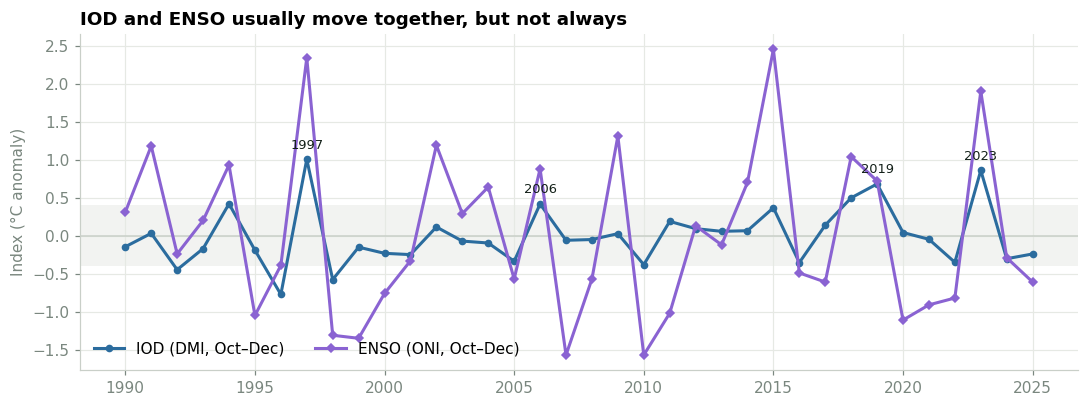

DMI vs ONI (Oct–Dec): r = 0.70, p = 2.4e-06
DMI trend: +0.08 °C per decade, p = 0.20
Positive IOD seasons: [1994, 1997, 2006, 2018, 2019, 2023]
Negative IOD seasons: [1992, 1996, 1998]


In [2]:
fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.array(YEARS)
ax.axhspan(-IOD_THRESHOLD, IOD_THRESHOLD, color=GRID, alpha=0.5, lw=0)
ax.axhline(0, color='#c9cfc8', lw=1)
ax.plot(x, dmi_s['OND'], color=DMI_C, lw=2, marker='o', ms=4, label='IOD (DMI, Oct–Dec)')
ax.plot(x, oni_s['OND'], color=ONI_C, lw=2, marker='D', ms=4, label='ENSO (ONI, Oct–Dec)')
for y in [1997, 2019, 2006, 2023]:
    ax.annotate(str(y), (y, dmi_s['OND'][y]), xytext=(0, 7), textcoords='offset points',
                ha='center', fontsize=8.5, color=INK)
ax.set_ylabel('Index (°C anomaly)')
ax.set_title('IOD and ENSO usually move together, but not always')
ax.legend(loc='lower left', ncol=2)
plt.tight_layout(); plt.show()

r, p = stats.pearsonr(dmi_s['OND'], oni_s['OND'])
t = stats.linregress(x, dmi_s['OND'])
print(f'DMI vs ONI (Oct–Dec): r = {r:.2f}, p = {p:.1e}')
print(f'DMI trend: {t.slope * 10:+.2f} °C per decade, p = {t.pvalue:.2f}')
positive = dmi_s['OND'][dmi_s['OND'] >= IOD_THRESHOLD].index.tolist()
negative = dmi_s['OND'][dmi_s['OND'] <= -IOD_THRESHOLD].index.tolist()
print('Positive IOD seasons:', positive)
print('Negative IOD seasons:', negative)

**Finding:** the IOD and ENSO are strongly linked over this period (r = 0.70). **All six positive-IOD seasons coincided with El Niño conditions** (ONI ≥ 0.5), and all three negative-IOD seasons (1992, 1996, 1998) with neutral or La Niña conditions. In strong years the two are nearly inseparable in this record. 2019 comes closest to an IOD-led event: a very strong positive IOD (+0.9 °C) with only a weak El Niño (ONI +0.7). Because of this overlap, Section 3 uses partial correlations to separate the two, which works only to the extent that the two indices differ in moderate years. The DMI has no significant trend over 1990–2025 (+0.08 °C per decade, p = 0.20).

The grey band marks ±0.4 °C, the threshold used to classify positive and negative IOD seasons in Section 5: six positive, three negative and 27 neutral seasons.

---
## 2. Which short-rains window? SON vs OND

In [3]:
def corr_table(season):
    rows = []
    for r in ORDER:
        y = rain[season][r]
        rd, pd_ = stats.pearsonr(dmi_s[season], y)
        ro, po = stats.pearsonr(oni_s[season], y)
        rows.append({'region': r, 'r_DMI': rd, 'p_DMI': pd_, 'r_ONI': ro, 'p_ONI': po})
    return pd.DataFrame(rows).set_index('region')

son_c, ond_c = corr_table('SON'), corr_table('OND')
pd.concat({'SON (Parts 1–2)': son_c, 'OND': ond_c}, axis=1).round(3)

SON (Parts 1–2)                         OND                \
                              r_DMI  p_DMI  r_ONI  p_ONI  r_DMI  p_DMI  r_ONI   
region                                                                          
Karamoja                      0.178  0.300 -0.054  0.754  0.329  0.050  0.227   
Eastern                       0.353  0.034  0.154  0.371  0.505  0.002  0.413   
Northern                      0.245  0.150  0.015  0.931  0.448  0.006  0.344   
Central                       0.480  0.003  0.258  0.128  0.587  0.000  0.427   
Western                       0.109  0.526 -0.058  0.739  0.258  0.129  0.182   
Lake Victoria basin           0.442  0.007  0.194  0.257  0.541  0.001  0.346   
Uganda (national)             0.327  0.052  0.092  0.592  0.497  0.002  0.378   

                            
                     p_ONI  
region                      
Karamoja             0.182  
Eastern              0.012  
Northern             0.040  
Central              0.009  
Western              0.289  
Lake Victoria basin  0.039  
Uganda (national)    0.023

In [4]:
pct = lambda s: 100 * (s / s.mean() - 1)
print('Rainfall anomaly (% of the 1990–2025 average) in the four strongest positive-IOD years')
pd.concat({'SON': pct(rain['SON']).loc[[1997, 2006, 2019, 2023]].T,
           'OND': pct(rain['OND']).loc[[1997, 2006, 2019, 2023]].T}, axis=1).round(0)

Rainfall anomaly (% of the 1990–2025 average) in the four strongest positive-IOD years


SON                     OND                  
year                 1997  2006  2019  2023  1997  2006  2019  2023
region                                                             
Karamoja             11.0  39.0  38.0   8.0  42.0  63.0  78.0   0.0
Eastern              -3.0  27.0  50.0  15.0  35.0  35.0  94.0   8.0
Northern              4.0  17.0  19.0  11.0  35.0  21.0  56.0  14.0
Central              20.0  -3.0  43.0  16.0  58.0  -3.0  68.0  23.0
Western              -4.0  -6.0  13.0   3.0  20.0  -1.0  20.0  12.0
Lake Victoria basin  12.0  -5.0  38.0  19.0  45.0   6.0  48.0  24.0
Uganda (national)     4.0   9.0  27.0  10.0  36.0  12.0  54.0  14.0

**Finding — the most important result in this notebook:** the window matters. In **September–November**, the IOD correlates with the short rains only in the south (Central r = 0.48, Lake Victoria basin r = 0.44, Eastern r = 0.35), and ENSO correlates nowhere. That is the null result from Parts 1–2. In **October–December**, the IOD correlation strengthens everywhere and is significant in **five of seven series** (Central r = 0.59, Lake Victoria basin 0.54, Eastern 0.51, national 0.50, Northern 0.45), with Karamoja borderline (p = 0.05). **ENSO becomes significant too** in the same five series.

1997 shows why. Its short rains were 36% above average nationally in October–December but only 4% above in September–November, because most of the extra rain fell in November and December. **The earlier ENSO null result was partly an artefact of leaving December out.** The rest of this notebook uses OND for the short rains.

---
## 3. IOD or ENSO? Partial correlations

In [5]:
def partial_r(y, x, control):
    # Correlation of x and y after removing the linear effect of `control` from both
    rx = sm.OLS(x.values, sm.add_constant(control.values)).fit().resid
    ry = sm.OLS(y.values, sm.add_constant(control.values)).fit().resid
    return stats.pearsonr(rx, ry)

rows = []
for r in ORDER:
    y = rain['OND'][r]
    a, pa = partial_r(y, dmi_s['OND'], oni_s['OND'])
    b, pb = partial_r(y, oni_s['OND'], dmi_s['OND'])
    rows.append({'region': r, 'r_DMI': ond_c.loc[r, 'r_DMI'], 'r_ONI': ond_c.loc[r, 'r_ONI'],
                 'partial_DMI|ONI': a, 'p_DMI|ONI': pa, 'partial_ONI|DMI': b, 'p_ONI|DMI': pb})
part = pd.DataFrame(rows).set_index('region')
part.round(3)

,r_DMI,r_ONI,partial_DMI|ONI,p_DMI|ONI,partial_ONI|DMI,p_ONI|DMI
region,,,,,,
Karamoja,0.329,0.227,0.244,0.152,-0.002,0.990
Eastern,0.505,0.413,0.333,0.047,0.098,0.569
Northern,0.448,0.344,0.310,0.066,0.049,0.775
Central,0.587,0.427,0.446,0.006,0.031,0.857
Western,0.258,0.182,0.186,0.277,0.003,0.986
Lake Victoria basin,0.541,0.346,0.446,0.006,-0.052,0.765
Uganda (national),0.497,0.378,0.351,0.036,0.052,0.764


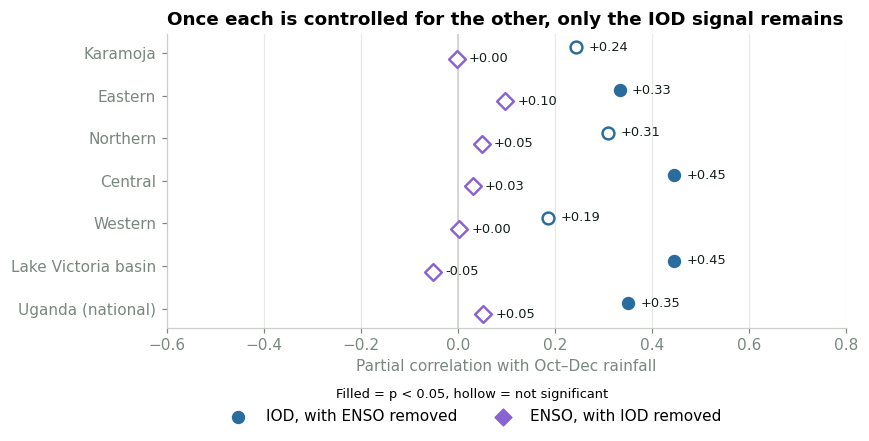

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ypos = np.arange(len(ORDER))[::-1]
ax.axvline(0, color='#c9cfc8', lw=1)
for col, pcol, c, m, off, lab in [('partial_DMI|ONI', 'p_DMI|ONI', DMI_C, 'o', 0.13, 'IOD, with ENSO removed'),
                                   ('partial_ONI|DMI', 'p_ONI|DMI', ONI_C, 'D', -0.13, 'ENSO, with IOD removed')]:
    sig = part[pcol] < 0.05
    ax.scatter(part[col][sig], ypos[sig.values] + off, color=c, marker=m, s=60, zorder=3, label=lab)
    ax.scatter(part[col][~sig], ypos[~sig.values] + off, facecolor='white', edgecolor=c, marker=m,
               s=60, lw=1.6, zorder=3)
    for v, yy in zip(part[col], ypos + off):
        ax.annotate(f'{round(v, 2) + 0.0:+.2f}', (v, yy), xytext=(8, 0), textcoords='offset points',
                    va='center', fontsize=8.5, color=INK)
ax.set_yticks(ypos); ax.set_yticklabels(ORDER)
ax.set_xlim(-0.6, 0.8)
ax.set_xlabel('Partial correlation with Oct–Dec rainfall')
ax.set_title('Once each is controlled for the other, only the IOD signal remains')
ax.grid(axis='y', visible=False)
ax.legend(loc='upper center', bbox_to_anchor=(0.45, -0.16), ncol=2,
          title='Filled = p < 0.05, hollow = not significant', title_fontsize=8.5)
plt.tight_layout(); plt.show()

**Finding:** with ENSO held fixed, the IOD still correlates with the short rains in Central and the Lake Victoria basin (partial r = 0.45, p = 0.006), Eastern and nationally (r ≈ 0.35, p < 0.05), with Northern borderline (p = 0.07). With the IOD held fixed, **ENSO's correlation falls to near zero everywhere** (−0.05 to +0.10, no p-value below 0.5). ENSO appears to affect Uganda's short rains *through* the IOD rather than on its own. This matches the published view that El Niño's wet East African short rains depend on the IOD response it triggers in the Indian Ocean.

Karamoja and the Western region show the weakest link. Karamoja's short rains are the tail of a single long wet season (Part 2), so an October–December signal is diluted there.

---
## 4. Robustness: is it just 1997 and 2019?

In [7]:
keep = ~rain['OND'].index.isin([1997, 2019])
rows = []
for r in ORDER:
    y = rain['OND'][r]
    rho, p_rho = stats.spearmanr(dmi_s['OND'], y)
    r_ex, p_ex = stats.pearsonr(dmi_s['OND'][keep], y[keep])
    rows.append({'region': r, 'pearson_r': ond_c.loc[r, 'r_DMI'], 'p': ond_c.loc[r, 'p_DMI'],
                 'spearman_rho': rho, 'p_spearman': p_rho, 'r_without_1997_2019': r_ex, 'p_without': p_ex})
robust = pd.DataFrame(rows).set_index('region')
robust.round(3)

,pearson_r,p,spearman_rho,p_spearman,r_without_1997_2019,p_without
region,,,,,,
Karamoja,0.329,0.050,0.336,0.045,0.177,0.316
Eastern,0.505,0.002,0.437,0.008,0.362,0.035
Northern,0.448,0.006,0.347,0.038,0.268,0.125
Central,0.587,0.000,0.375,0.024,0.358,0.038
Western,0.258,0.129,0.175,0.307,0.083,0.640
Lake Victoria basin,0.541,0.001,0.370,0.026,0.318,0.067
Uganda (national),0.497,0.002,0.357,0.033,0.298,0.087


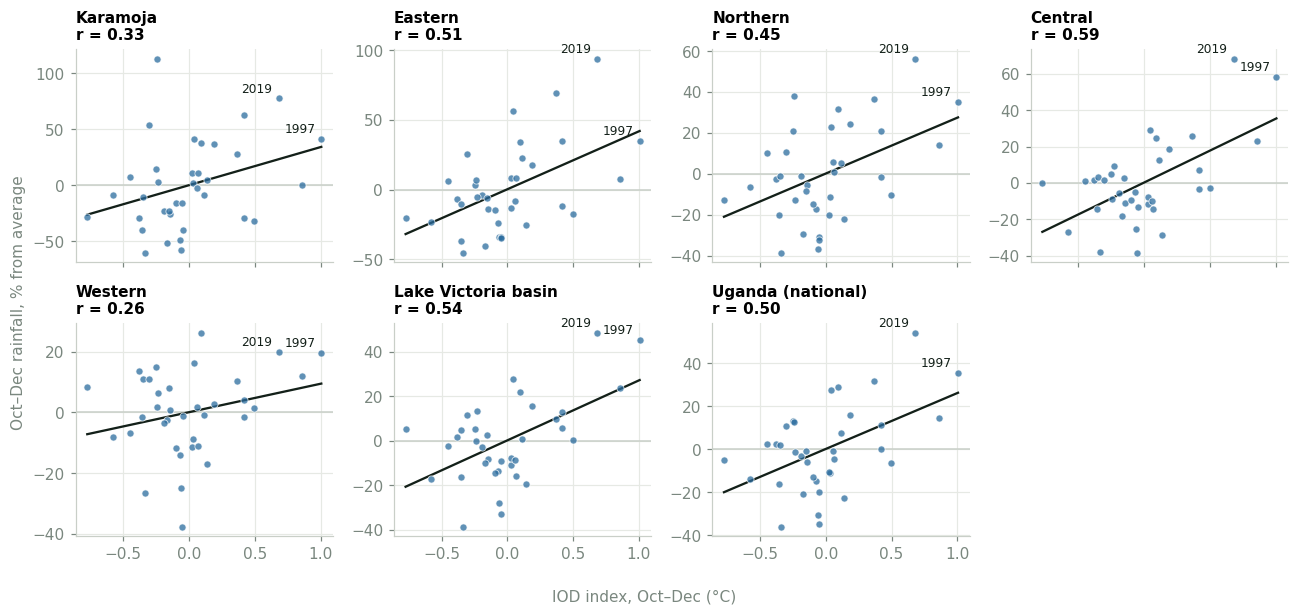

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(12, 5.6), sharex=True)
for ax, r in zip(axes.flat, ORDER):
    x_, y_ = dmi_s['OND'], pct(rain['OND'][r])
    ax.axhline(0, color='#c9cfc8', lw=1)
    ax.scatter(x_, y_, s=22, color=WET, alpha=0.75, edgecolor='white', lw=0.6, zorder=3)
    fit = stats.linregress(x_, y_)
    xs = np.linspace(x_.min(), x_.max(), 10)
    ax.plot(xs, fit.intercept + fit.slope * xs, color=INK, lw=1.5)
    for yr in [1997, 2019]:
        ax.annotate(str(yr), (x_[yr], y_[yr]), xytext=(-4, 4), textcoords='offset points',
                    ha='right', fontsize=8, color=INK)
    ax.set_title(f'{r}\nr = {fit.rvalue:.2f}', fontsize=10)
axes.flat[-1].axis('off')
fig.supxlabel('IOD index, Oct–Dec (°C)', color=MUTED, fontsize=10)
fig.supylabel('Oct–Dec rainfall, % from average', color=MUTED, fontsize=10)
plt.tight_layout(); plt.show()

**Finding:** the relationship is real but leans on the extremes. The rank-based Spearman test, which is not driven by extreme values, is weaker (ρ ≈ 0.35–0.44) but still significant everywhere except the Western region. **Removing 1997 and 2019, the two strongest positive-IOD years, cuts the correlations by about 40%**, to r ≈ 0.3. Only Central and Eastern stay significant (p ≈ 0.04), with the Lake Victoria basin and national series borderline (p ≈ 0.07–0.09).

A fair reading: the IOD's influence is clearest in strong events, which bring very wet short rains across the country. In ordinary years it explains much less. With 36 years and only a handful of strong events, that distinction can't be settled with this record alone.

---
## 5. Composites: rainfall in positive, neutral and negative IOD years

In [9]:
phase = pd.Series('Neutral', index=dmi_s['OND'].index)
phase[dmi_s['OND'] >= IOD_THRESHOLD] = 'Positive IOD'
phase[dmi_s['OND'] <= -IOD_THRESHOLD] = 'Negative IOD'
print(phase.value_counts().to_string(), '\n')

anom = pct(rain['OND'])
comp = anom.groupby(phase).mean().T[['Positive IOD', 'Neutral', 'Negative IOD']]
comp['p_pos_vs_neutral'] = [stats.ttest_ind(rain['OND'][r][phase == 'Positive IOD'],
                                            rain['OND'][r][phase == 'Neutral'], equal_var=False).pvalue
                            for r in ORDER]
comp.round(2)

Neutral         27
Positive IOD     6
Negative IOD     3 



,Positive IOD,Neutral,Negative IOD,p_pos_vs_neutral
region,,,,
Karamoja,20.21,-3.38,-9.95,0.29
Eastern,23.63,-3.87,-12.47,0.17
Northern,19.09,-3.92,-2.94,0.07
Central,25.23,-4.64,-8.67,0.07
Western,9.27,-1.81,-2.26,0.04
Lake Victoria basin,22.67,-4.51,-4.72,0.02
Uganda (national),18.29,-3.46,-5.45,0.07


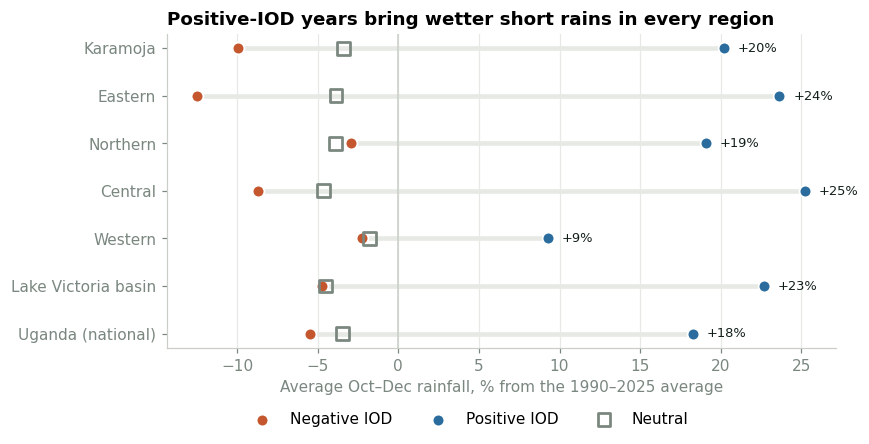

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ypos = np.arange(len(ORDER))[::-1]
ax.axvline(0, color='#c9cfc8', lw=1)
for r_, yy in zip(ORDER, ypos):
    ax.plot([comp.loc[r_, 'Negative IOD'], comp.loc[r_, 'Positive IOD']], [yy, yy], color=GRID, lw=3, zorder=1)
ax.scatter(comp['Negative IOD'], ypos, color=DRY, s=60, zorder=3, label='Negative IOD', edgecolor='white', lw=1.2)
ax.scatter(comp['Positive IOD'], ypos, color=WET, s=60, zorder=3, label='Positive IOD', edgecolor='white', lw=1.2)
# Neutral drawn hollow and on top, so a dot underneath stays visible
ax.scatter(comp['Neutral'], ypos, facecolor='none', edgecolor=MUTED, marker='s', s=70, lw=1.8, zorder=4, label='Neutral')
for r_, yy in zip(ORDER, ypos):
    v = comp.loc[r_, 'Positive IOD']
    ax.annotate(f'{v:+.0f}%', (v, yy), xytext=(9, 0), textcoords='offset points', va='center', fontsize=8.5, color=INK)
ax.set_yticks(ypos); ax.set_yticklabels(ORDER)
ax.set_xlabel('Average Oct–Dec rainfall, % from the 1990–2025 average')
ax.set_title('Positive-IOD years bring wetter short rains in every region')
ax.grid(axis='y', visible=False)
ax.legend(loc='upper center', bbox_to_anchor=(0.45, -0.16), ncol=3)
plt.tight_layout(); plt.show()

**Finding:** the direction is the same in every region. In the six positive-IOD seasons, October–December rainfall averaged **18% above normal nationally**, from +9% in the Western region to +25% in Central, against slightly below-normal rainfall (−2 to −5%) in neutral years. The three negative-IOD seasons were drier still in most regions (down to −12% in the Eastern region).

With so few events, though, the positive-versus-neutral difference reaches p < 0.05 only in the Lake Victoria basin and the Western region (p = 0.07–0.29 elsewhere), and none survives the multiple-testing correction in Section 8. The practical reading: **a strong positive IOD in September–October is a warning sign of a wet short-rains season**, but this record alone can't say how reliable that warning is.

---
## 6. Does the IOD explain the short-rains trend?

In [11]:
rows = []
for season in ['SON', 'OND']:
    for r in ORDER:
        y = rain[season][r]
        yrs = np.array(y.index, dtype=float)
        base = sm.OLS(y.values, sm.add_constant(yrs)).fit()
        X = sm.add_constant(np.column_stack([yrs, dmi_s[season].values]))
        ctrl = sm.OLS(y.values, X).fit()
        rows.append({'season': season, 'region': r,
                     'trend_mm_yr': base.params[1], 'trend_p': base.pvalues[1],
                     'trend_with_DMI': ctrl.params[1], 'p_with_DMI': ctrl.pvalues[1],
                     'R2_trend_only': base.rsquared, 'R2_trend_plus_DMI': ctrl.rsquared})
trend_ctrl = pd.DataFrame(rows).set_index(['season', 'region'])
trend_ctrl.round(3)

trend_mm_yr  trend_p  trend_with_DMI  p_with_DMI  \
season region                                                                  
SON    Karamoja                   3.476    0.001           3.375       0.003   
       Eastern                    3.564    0.017           2.991       0.043   
       Northern                   1.723    0.036           1.528       0.067   
       Central                    0.876    0.375           0.260       0.775   
       Western                    0.984    0.169           0.928       0.212   
       Lake Victoria basin        0.896    0.292           0.417       0.603   
       Uganda (national)          1.636    0.045           1.342       0.099   
OND    Karamoja                   2.541    0.019           2.173       0.044   
       Eastern                    2.894    0.094           1.848       0.239   
       Northern                   1.443    0.135           0.929       0.304   
       Central                    1.123    0.391           0.149       0.893   
       Western                    0.908    0.265           0.671       0.415   
       Lake Victoria basin        1.062    0.329           0.325       0.735   
       Uganda (national)          1.452    0.151           0.844       0.360   

                            R2_trend_only  R2_trend_plus_DMI  
season region                                                 
SON    Karamoja                     0.260              0.264  
       Eastern                      0.156              0.229  
       Northern                     0.123              0.152  
       Central                      0.023              0.232  
       Western                      0.055              0.058  
       Lake Victoria basin          0.033              0.202  
       Uganda (national)            0.113              0.179  
OND    Karamoja                     0.151              0.213  
       Eastern                      0.080              0.286  
       Northern                     0.065              0.226  
       Central                      0.022              0.344  
       Western                      0.036              0.085  
       Lake Victoria basin          0.028              0.295  
       Uganda (national)            0.060              0.266

**Finding:** the IOD **does not explain Karamoja's wetting trend**. Karamoja's September–November trend barely moves when the IOD is added (+3.5 → +3.4 mm/yr, still p = 0.003). Its October–December trend shrinks a little (+2.5 → +2.2 mm/yr) but stays significant (p = 0.04). The IOD has no trend of its own over 1990–2025, so it can't account for a steady rise.

The **Eastern** SON trend shrinks slightly (+3.6 → +3.0 mm/yr, p = 0.04), and the borderline national and Northern SON trends lose significance once the IOD is included. The IOD does explain a large share of the year-to-year variation instead: in the Central region, adding it raises the explained variance of October–December rainfall from 2% to 34%. Part of their apparent rise reflects the cluster of strong positive-IOD years late in the record (2019, 2023). Karamoja's rise is something else: possibly a longer-term change in regional circulation, or a change in CHIRPS's inputs over time, which is worth checking against station data.

---
## 7. The long rains (March–May)

In [12]:
mam_c = corr_table('MAM')
mam_c.round(3)

,r_DMI,p_DMI,r_ONI,p_ONI
region,,,,
Karamoja,-0.013,0.942,-0.058,0.738
Eastern,0.103,0.551,-0.138,0.423
Northern,-0.096,0.579,0.004,0.979
Central,0.059,0.732,-0.111,0.520
Western,-0.180,0.293,-0.044,0.800
Lake Victoria basin,0.071,0.679,-0.072,0.675
Uganda (national),-0.056,0.744,-0.055,0.749


**Finding:** neither index is related to the long rains in any region (all |r| < 0.2, no p-value below 0.29). This is expected: the IOD is usually inactive from December to May. The long rains, the more important planting season for most of Uganda, get no early-warning signal from these indices.

---
## 8. Multiple-testing check

In [13]:
pvals = pd.concat({
    'OND r_DMI': ond_c['p_DMI'], 'OND r_ONI': ond_c['p_ONI'],
    'SON r_DMI': son_c['p_DMI'], 'SON r_ONI': son_c['p_ONI'],
    'partial DMI|ONI': part['p_DMI|ONI'], 'partial ONI|DMI': part['p_ONI|DMI'],
    'MAM r_DMI': mam_c['p_DMI'], 'MAM r_ONI': mam_c['p_ONI'],
    'pos vs neutral': comp['p_pos_vs_neutral'],
})
reject, q, _, _ = multipletests(pvals.values, alpha=0.05, method='fdr_bh')
checked = pd.DataFrame({'p': pvals, 'q_FDR': q, 'survives_FDR': reject})
print(f'Tests: {len(pvals)}   Bonferroni threshold: {0.05 / len(pvals):.5f}   Survive FDR 5%: {reject.sum()}')
checked[checked['p'] < 0.05].sort_values('p').round(4)

Tests: 63   Bonferroni threshold: 0.00079   Survive FDR 5%: 9


p   q_FDR  survives_FDR
                region                                           
OND r_DMI       Central              0.0002  0.0107          True
                Lake Victoria basin  0.0007  0.0206          True
                Eastern              0.0017  0.0325          True
                Uganda (national)    0.0021  0.0325          True
SON r_DMI       Central              0.0031  0.0387          True
OND r_DMI       Northern             0.0061  0.0487          True
partial DMI|ONI Lake Victoria basin  0.0064  0.0487          True
                Central              0.0064  0.0487          True
SON r_DMI       Lake Victoria basin  0.0070  0.0487          True
OND r_ONI       Central              0.0095  0.0597         False
                Eastern              0.0124  0.0709         False
pos vs neutral  Lake Victoria basin  0.0197  0.1036         False
OND r_ONI       Uganda (national)    0.0229  0.1112         False
SON r_DMI       Eastern              0.0345  0.1403         False
partial DMI|ONI Uganda (national)    0.0357  0.1403         False
pos vs neutral  Western              0.0373  0.1403         False
OND r_ONI       Lake Victoria basin  0.0388  0.1403         False
                Northern             0.0401  0.1403         False
partial DMI|ONI Eastern              0.0469  0.1545         False

**Finding:** 63 tests were run. Using the Benjamini–Hochberg false discovery rate (a standard correction when many related tests are run), nine results survive: the October–December IOD correlations for Central, the Lake Victoria basin, Eastern, Northern and the national series; the September–November IOD correlations for Central and the Lake Victoria basin; and the IOD partial correlations for Central and the Lake Victoria basin. No ENSO correlation and no composite difference survives. The core conclusion, that the IOD matters for the October–December short rains, holds up after correction.

---
## Export

In [14]:
out = pd.concat({'OND': ond_c, 'SON': son_c, 'MAM': mam_c}, names=['season'])
out.round(4).to_csv('../data/processed/iod_enso_correlations.csv')
part.round(4).to_csv('../data/processed/iod_partial_correlations.csv')
trend_ctrl.round(4).to_csv('../data/processed/iod_trend_control.csv')
print('Saved: iod_enso_correlations.csv, iod_partial_correlations.csv, iod_trend_control.csv')

Saved: iod_enso_correlations.csv, iod_partial_correlations.csv, iod_trend_control.csv


---
## Summary

**What Part 3 shows**
- **The IOD drives much of the short rains' year-to-year swings.** Using October–December, it correlates significantly with rainfall in five of seven series (national r = 0.50), and positive-IOD seasons averaged 18% wetter nationally. The link is strongest in the south and centre (Central, Lake Victoria basin) and weakest in Karamoja and the west.
- **ENSO matters mainly through the IOD.** Once the IOD is controlled for, ENSO's correlation disappears.
- **The Parts 1–2 ENSO null result was partly a window artefact.** September–November leaves out December, where much of the extra rain in strong events falls.
- **The signal is strongest in big events.** Without 1997 and 2019 the correlations fall by about 40%.
- **The IOD does not explain Karamoja's wetting trend.** That trend survives almost unchanged and needs another explanation.
- **The long rains show no link** to either index.

**Caveats**
- The IOD and ENSO are strongly correlated, and 36 years contain only a few strong events, so the partial correlations rest on a small number of informative years.
- CHIRPS is a satellite–gauge blend; trends in it can partly reflect changes in the station network.
- Correlation is not mechanism. The physical link (warm western Indian Ocean → more moisture and convection over East Africa) is well documented elsewhere and is assumed here, not tested.

**Suggested next steps**
1. Check Karamoja's trend against station records or a second rainfall product (e.g. ERA5 or TAMSAT).
2. Test whether a September DMI forecast predicts October–December rainfall well enough to be useful as an early warning.
3. Look at rainfall intensity and rainy-day counts, not only totals.

---
*DMI: HadISST1.1, NOAA PSL (`dmi.had.long.data`); recent months are preliminary. ONI: ERSSTv5, NOAA CPC (`oni.ascii.txt`). Re-download both with `python scripts/fetch_climate_indices.py`.*